In [4]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np

from scipy.spatial.distance import pdist


def random_latin_hypercube(
        n:int, 
        k:int,
        lb: float = 0,
        ub: float = 1
    ) -> np.ndarray:
    """
    Generate a random Latin hypercube sampling plan in k dimensions.

    Each dimension is partitioned into n equal-width bins, and the plan
    places exactly one point per bin in every dimension (the Latin
    hypercube property), giving more uniform coverage of the domain than
    independent uniform sampling. Points are positioned at bin centres and
    then scaled from the unit hypercube [0, 1]^k onto [lb, ub]^k.

    Parameters
    ----------
    n : int
        Number of sample points. Also the number of bins per dimension,
        since the plan places one point per bin.
    k : int
        Number of dimensions (design variables).
    lb : float, optional
        Lower bound of the domain in every dimension (default 0).
    ub : float, optional
        Upper bound of the domain in every dimension (default 1).
        Must satisfy ub > lb.

    Returns
    -------
    np.ndarray
        An (n, k) array of sample points. Each column is a permutation of
        the same n bin centres, mapped to [lb, ub].

    Raises
    ------
    ValueError
        If ub <= lb.
    """
    
    if ub <= lb:
        raise ValueError("upper bound must be greater than lower bound")
    
    rng = np.random.default_rng()

    X = np.zeros((n,k))

    for i in range(k):
        X[:,i] = rng.permutation(n)
    
    X = (X + 0.5)/n
    w = ub - lb

    X_scaled = lb + w*X

    return X_scaled


# 2 Constructing a Surrogate

## 2.3 Radial Basis Function Models

$$f(x) = \mathbf{w}^T \mathbf{\psi} = \sum_{i=1}^{n_c}w_i\psi(\left\lVert x-c^{(i)} \right\rVert)$$

In [24]:
def psi_radial_dist() -> np.ndarray:
    return

def psi_gram_matrix(X: np.ndarray) -> np.ndarray:
    return X.transpose

X = random_latin_hypercube(20,2,-3,3)

print(X.shape)
print(X)

[[-2.25 -1.95]
 [-1.95  2.85]
 [-1.05 -0.15]
 [-0.45 -2.55]
 [-1.35  2.25]
 [ 2.25 -2.85]
 [-0.15 -0.45]
 [ 0.15 -1.65]
 [ 1.05  1.35]
 [-1.65 -1.35]
 [ 0.75 -2.25]
 [ 0.45  1.65]
 [ 2.55  2.55]
 [ 1.95  1.05]
 [-0.75 -0.75]
 [ 1.35  0.75]
 [-2.85  0.15]
 [-2.55 -1.05]
 [ 2.85  0.45]
 [ 1.65  1.95]]
(20, 2)


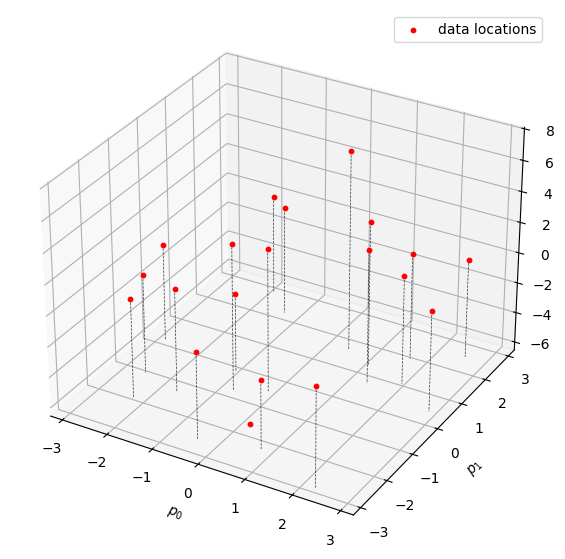

In [60]:

# define a toy modeling target "peaks"
def peaks(x, y):
    return (3 * (1 - x)**2 * np.exp(-x**2 - (y + 1)**2)
            - 10 * (x/5 - x**3 - y**5) * np.exp(-x**2 - y**2)
            - 1/3 * np.exp(-(x + 1)**2 - y**2))

# define parameters: p0, p1
True
# define the target for modeling as a function M: Dom -> Ran for domain space Dom and range space Ran
modeled_process = peaks
# define the feasible set by fixing the ranges of each parameter
p0_range = (-3, 3)
p1_range = (-3, 3)
# define the data set
datax = X
datay = modeled_process(datax[:,0], datax[:,1]).reshape(-1,1)
# print(datay)

# helper
def quick_view(npoints: int, datax: np.array, datay: np.array, show_model = True):
    p0s = np.linspace(*p0_range, npoints)
    p1s = np.linspace(*p1_range, npoints)
    ps0, ps1 = np.meshgrid(p0s, p1s)
    model_out = modeled_process(ps0, ps1)
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    if show_model:
        surf = ax.plot_surface(ps0, ps1, model_out, cmap='Purples', linewidth=0, antialiased=True, alpha=0.5)

    ax.set_zlim(np.min(model_out), np.max(model_out))

    datax0, datax1 = datax[:,0], datax[:,1]
    ax.scatter(datax0, datax1, datay[:,0], color='red', s=10, label='data locations', depthshade=False, zorder=100)

    for i in range(len(datax[:,0])):
        ax.plot3D(
            [datax0[i], datax0[i]],
            [datax1[i], datax1[i]],
            [datay[i,0], np.min(model_out)],
            color='black',
            linestyle='--',
            linewidth=0.5, 
            alpha=0.8
        )
    
    ax.set_xlabel('$p_0$')
    ax.set_ylabel('$p_1$')
    ax.set_zlabel('$M(p)$')
    if show_model:
        fig.colorbar(surf, shrink=0.5, aspect=10)
    ax.legend()

# pause to inspect the modeled process
# quick_view(10, datax, datay)
# quick_view(30, datax, datay)
quick_view(100, datax, datay, show_model=False)

In [89]:
# define some possible radial basis functions
def rbf_linear(r):
    return r

def rbf_cubic(r):
    return r**3

def rbf_thin_plate_spline(r):
    if r < 1e-200:
        return 0
    else:
        return r**2*np.log(r)

def rbf_gaussian(r, sigma = 1):
    return np.exp(-(r**2)/(2*sigma**2))

def rbf_multiquadratic(r, sigma = 1):
    return np.sqrt(r**2 + sigma**2)

def rbf_inverse_multiquadratic(r, sigma = 1):
    return 1.0/rbf_multiquadratic(r, sigma)

class RBF_Model:
    """

    """
    def __init__(self, rbf_function, datax, datay):
        # dataset size
        self.n = datax.shape[0]
        self.datax = datax
        self.datay = datay
        # radial basis function
        self.rbf_function = rbf_function
        # cached values
        self.Psi = self.get_Psi()
        self.weights = self.get_rbf_weights()
    
    def get_Psi(self):
        Psi = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(self.n):
                Psi[i,j] = self.rbf_function(self.dist(datax[i,:], datax[j,:]))
        return Psi
    
    def dist(self,x1,x2):
        return np.linalg.norm(x1-x2)
    
    # define the model weight evaluator
    def get_rbf_weights(self):
        Psi = self.Psi
        y = self.datay[:,0]
        # solve the system y = Psi*weights
        weights = np.linalg.solve(Psi, y)
        return weights

    def evaluate(self, x):
        # these values are not known until the point x is given
        coweights = np.zeros(self.n)
        for i in range(self.n):
            coweights[i] = self.rbf_function(self.dist(x, self.datax[i]))
        return np.dot(self.weights, coweights)

rbf_model = RBF_Model(rbf_linear, datax, datay)
# rbf_model = RBF_Model(rbf_cubic, datax, datay)
# rbf_model = RBF_Model(rbf_gaussian, datax, datay)
print("weights: ", rbf_model.weights)

# try some values
def try_value(x_test):
    print(f"surrogate model predicts: y {rbf_model.evaluate(x=x_test)}")
    print(f"modeled process yields: y {modeled_process(x_test[0],x_test[1])}")

try_value([0,0])
try_value([1,0])
try_value([0,1])
try_value([1,1])


weights:  [-0.03909076  0.25908441  5.07379903 -1.49860739  0.79831272 -0.52867692
 -2.7238743   7.75049795  1.12412407 -0.0902296  -1.41019932 -4.73581231
  0.12020586  0.48720897 -5.32957254 -0.70867211 -0.24663108  0.02211427
 -0.04600661  1.67125544]
surrogate model predicts: y 2.548200058257944
modeled process yields: y 0.9810118431238463
surrogate model predicts: y 1.5364560004201295
modeled process yields: y 2.936930316408627
surrogate model predicts: y 3.915831085523317
modeled process yields: y 3.688629567301755
surrogate model predicts: y 3.0575553155911095
modeled process yields: y 2.4337891159260003
